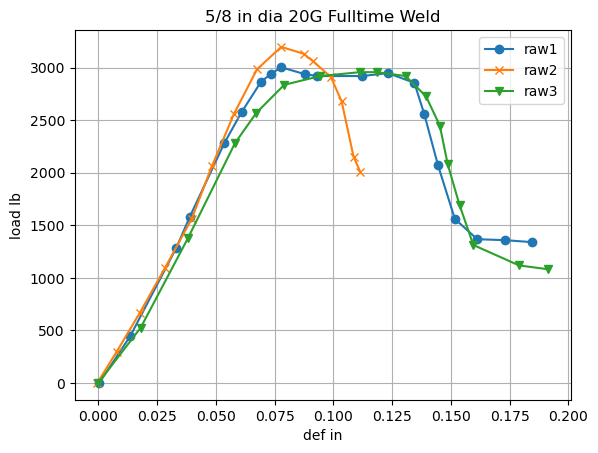

In [318]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import numpy as np

raw1 = np.array([
    [0.0003254251522149809, 434.1801385681292],
    [0.013456950355963573, 877.5981524249423],
    [0.03311797377512262, 1718.2448036951505],
    [0.038842020880651994, 2013.856812933026],
    [0.05357299639264788, 2715.9353348729796],
    [0.0609499360601607, 3011.547344110855],
    [0.06915523066058443, 3297.921478060047],
    [0.0732721928501899, 3371.8244803695156],
    [0.07780428683221038, 3436.489607390301],
    [0.08773500276754526, 3371.8244803695156],
    [0.09311072089782987, 3353.3487297921483],
    [0.1121189853606398, 3353.3487297921483],
    [0.12327028419827074, 3381.062355658199],
    [0.13444639551085066, 3288.683602771363],
    [0.13863970377722212, 2993.0715935334874],
    [0.1445259862958792, 2503.4642032332567],
    [0.15165575553986219, 1995.3810623556583],
    [0.16119996946156928, 1801.3856812933027],
    [0.1731853491878686, 1792.1478060046193],
    [0.1843461912850953, 1773.672055427252]
])

raw2 = np.array([
    [-0.000499112476857605, 424.94226327944534],
    [0.007704273471646962, 720.5542725173209],
    [0.017545282766781807, 1090.0692840646652],
    [0.028201286431393503, 1515.011547344111],
    [0.039674193117401176, 1986.1431870669749],
    [0.048248811864180306, 2484.9884526558894],
    [0.0576498768919512, 2983.833718244804],
    [0.06747943427557115, 3408.77598152425],
    [0.07776611379382742, 3621.2471131639727],
    [0.08728360658866641, 3556.5819861431874],
    [0.09143110720897829, 3482.678983833719],
    [0.09889966216861029, 3334.8729792147815],
    [0.1034928330120436, 3103.9260969976913],
    [0.10856030385738552, 2577.367205542726],
    [0.11148340427156297, 2429.561200923788]
])

raw3 = np.array([
    [-0.00008588933636172885, 424.94226327944534],
    [0.01798713568606492, 951.5011547344111],
    [0.03805947359380069, 1801.3856812933027],
    [0.05812035959002155, 2706.697459584296],
    [0.06715210047143702, 2993.0715935334874],
    [0.07908022064016185, 3260.9699769053123],
    [0.09435229897123662, 3344.110854503465],
    [0.11128681312389058, 3381.062355658199],
    [0.11872482965281622, 3381.062355658199],
    [0.130715935334873, 3344.110854503465],
    [0.13943370297558833, 3150.1154734411093],
    [0.14527608650010496, 2872.979214780601],
    [0.14865821770083787, 2503.4642032332567],
    [0.15369705876739256, 2115.473441108545],
    [0.15956043746301987, 1736.7205542725173],
    [0.17902200675662777, 1542.7251732101618],
    [0.1914263355791804, 1505.7736720554276]
])
x1= raw1[:,0]
y1 = raw1[:,1]-434.1801385681292
x2= raw2[:,0]
y2 = raw2[:,1]-424.94226327944534
x3= raw3[:,0]
y3 = raw3[:,1]-424.94226327944534
plt.figure()
plt.plot(x1,y1,marker='o',label="raw1")
plt.plot(x2,y2,marker='x',label="raw2")
plt.plot(x3,y3,marker='v',label="raw3")
plt.ylabel('load lb')
plt.xlabel('def in')
plt.title("5/8 in dia 20G Fulltime Weld")
plt.grid(True)
plt.legend()
plt.show()

In [320]:
def support_group(n_col, n_row, col_spacing, row_spacing):
    x_support = []
    y_support = []
    for i in range(n_col):
        for j in range(n_row):
            x_support.append(i * col_spacing - (n_col - 1) * col_spacing / 2)
            y_support.append(j * row_spacing - (n_row - 1) * row_spacing / 2)
    return x_support, y_support

In [322]:
def force_from_curve(delta_i, delta_tab,force_tab, normalize_by = None):
    # castining deformations and force values into numpy arrays b/c NumPy arrays let us do fast, vectorized math
    delta_tab = np.asarray(delta_tab,dtype=float) 
    force_tab = np.asarray(force_tab,dtype=float)
    x = np.asarray(delta_tab, float)
    y = np.asarray(force_tab, float)

    #cliping delta values to the range using clipping If value < min_val, it gets replaced by min_val. Same is true the other way
    xi = np.clip(np.asarray(delta_i, float), x.min(), x.max()) #so if delta_i is < minimum deformation it is xmin (same for xmax), this is b/c We don’t want to interpolate outside the tabulated data range. 
    f = np.interp(xi, x, y)              # capped interpolation
    f = np.clip(f, 0.0, y.max())         # guard against tiny numeric overshoots, f < 0.0 → set it to 0., If f > y.max() → set it to y.max().
    if normalize_by is not None:
        f = np.clip(f / float(normalize_by), 0.0, 1.0) # we are making sure Makes sure normalized FORCE results are always between 0 and 1. We use this
        # if we normalize by pf_arc
    return f

In [324]:
def ICM1(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max,lamda):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        
# Computing deformation component _______________________________________________
        df['ux'] = df['dx'] / (df['d'] + eps)
        df['uy'] = df['dy'] / (df['d'] + eps)

        # unit tangential direction (perpendicular to radial)
        df['tx'] = -df['uy']
        df['ty'] =  df['ux']

        # choose theta so that max slip magnitude equals delta_max
        theta = delta_max / (df['d'].max() + eps)

        # tangential slip vector components (this is the deformation direction in ICM)
        df['delta_x'] = theta * df['d'] * df['tx']
        df['delta_y'] = theta * df['d'] * df['ty']

        # slip magnitude (what you were using before)
        df['delta'] = np.hypot(df['delta_x'], df['delta_y'])

        def get_force_components(row):
            alpha_y = 0
            t = row['Fastener type']
        
            # normalized force ratio based on slip magnitude
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                r = force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
            # apply efficiency
                if t == 'EndArc':
                    r *= lamda
                elif t == 'EdgeArc':
                    r *= lamda

            
            elif t == 'SideScrew':
                r = screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
        
            # split that ratio into x/y components based on deformation direction
            # then weaken the y direction
            denom = (row['delta'] + eps)
            rx_ratio = r * (row['delta_x'] / denom)
            ry_ratio = r * (row['delta_y'] / denom) * alpha_y
        
            return pd.Series({'Rx_ratio': rx_ratio, 'Ry_ratio': ry_ratio})

        ratios = df.apply(get_force_components, axis=1)
        df = pd.concat([df, ratios], axis=1)

        df['R_ratio_mag'] = np.hypot(df['Rx_ratio'], df['Ry_ratio'])
        df['M'] = df['R_ratio_mag'] * df['d']
        sumMi = df['M'].sum()
        Rult = -Mp / (sumMi + eps)

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        df['Rx'] = df['Rx_ratio'] * Rult
        df['Ry'] = df['Ry_ratio'] * Rult




        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*0
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi,P_f_arc 



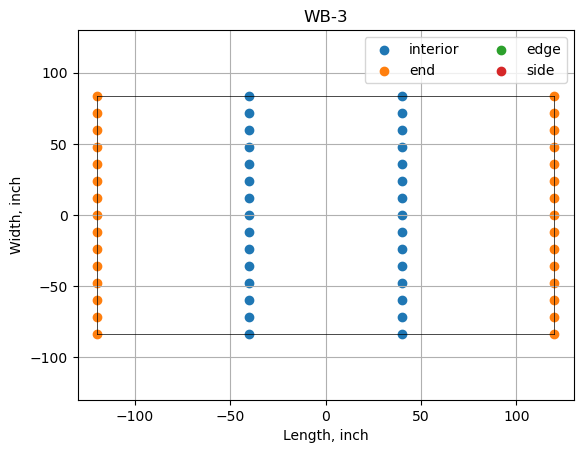

In [340]:
#WB 3 
interior_x, interior_y = support_group(n_col=2, n_row=15, col_spacing=80, row_spacing=12)
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]


plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-3')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [342]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = +120 , 96   # in
L = 20 


delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.480))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.401))

Iter   0 | F = 5.319432e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 4.036615e-01 | IC = (-0.00, -26.52)
Iter  20 | F = 4.122826e-01 | IC = (-0.00, -26.14)
Iter  30 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  40 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  50 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  60 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  70 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  80 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter  90 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 100 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 110 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 120 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 130 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 140 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 150 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 160 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 170 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 180 | F = 4.122818e-01 | IC = (-0.00, -26.14)
Iter 190 | F = 4.122818e-01 | 

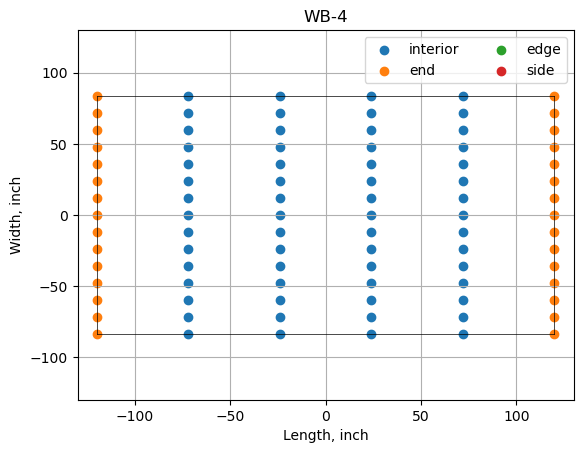

In [344]:
#_______________WB4__________________________________________________
interior_x, interior_y = support_group(4,15,12*4, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-4')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [350]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (4*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = 120 , 96   # in
L = 20 


delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.775))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.665))

Iter   0 | F = 5.255296e-01 | IC = (-0.00, -98.00)
Iter  10 | F = 7.933715e-02 | IC = (-0.00, -40.81)
Iter  20 | F = 1.067553e-01 | IC = (-0.00, -39.50)
Iter  30 | F = 1.168793e-01 | IC = (-0.00, -39.02)
Iter  40 | F = 1.207663e-01 | IC = (-0.00, -38.84)
Iter  50 | F = 1.222180e-01 | IC = (-0.00, -38.77)
Iter  60 | F = 1.227549e-01 | IC = (-0.00, -38.75)
Iter  70 | F = 1.229527e-01 | IC = (-0.00, -38.74)
Iter  80 | F = 1.230255e-01 | IC = (-0.00, -38.74)
Iter  90 | F = 1.230522e-01 | IC = (-0.00, -38.74)
Iter 100 | F = 1.230621e-01 | IC = (-0.00, -38.73)
Iter 110 | F = 1.230657e-01 | IC = (-0.00, -38.73)
Iter 120 | F = 1.230670e-01 | IC = (-0.00, -38.73)
Iter 130 | F = 1.230675e-01 | IC = (-0.00, -38.73)
Iter 140 | F = 1.230677e-01 | IC = (-0.00, -38.73)
Iter 150 | F = 1.230677e-01 | IC = (-0.00, -38.73)
Iter 160 | F = 1.230678e-01 | IC = (-0.00, -38.73)
Iter 170 | F = 1.230678e-01 | IC = (-0.00, -38.73)
Iter 180 | F = 1.230678e-01 | IC = (-0.00, -38.73)
Iter 190 | F = 1.230678e-01 | I

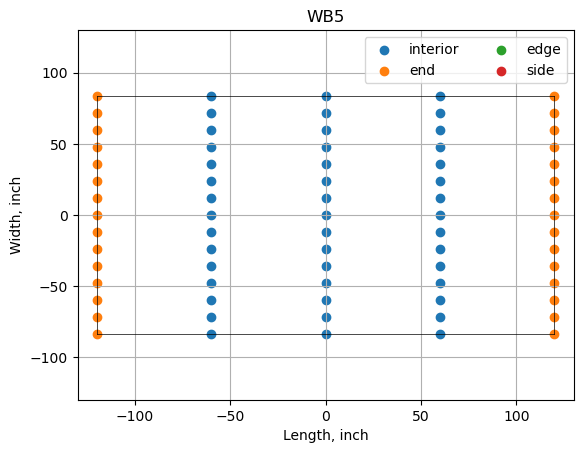

In [354]:
#_______________WB5__________________________________________________
interior_x, interior_y = support_group(3,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB5')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [362]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 


delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.525))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.440))

Iter   0 | F = 5.278854e-01 | IC = (-0.00, -103.00)
Iter  10 | F = 1.620684e-01 | IC = (-0.00, -36.79)
Iter  20 | F = 2.088805e-01 | IC = (-0.00, -35.10)
Iter  30 | F = 2.461991e-01 | IC = (-0.00, -33.36)
Iter  40 | F = 2.509673e-01 | IC = (-0.00, -33.14)
Iter  50 | F = 2.514955e-01 | IC = (-0.00, -33.12)
Iter  60 | F = 2.515530e-01 | IC = (-0.00, -33.11)
Iter  70 | F = 2.515593e-01 | IC = (-0.00, -33.11)
Iter  80 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter  90 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 100 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 110 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 120 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 130 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 140 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 150 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 160 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 170 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 180 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 190 | F = 2.515600e-01 | 

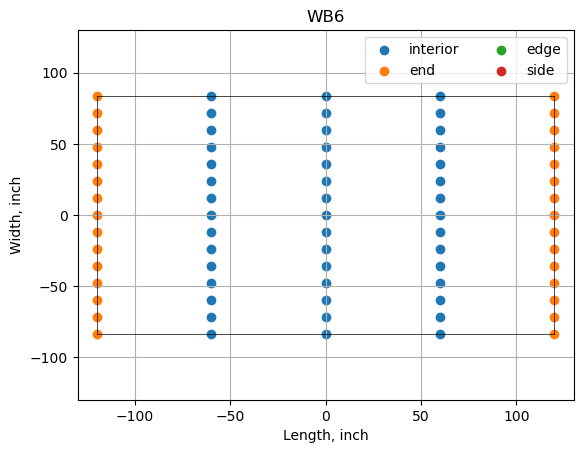

In [364]:
#_______________WB6__________________________________________________
interior_x, interior_y = support_group(3,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB6')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [370]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 


delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.58))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.398))

Iter   0 | F = 5.278854e-01 | IC = (-0.00, -103.00)
Iter  10 | F = 1.620684e-01 | IC = (-0.00, -36.79)
Iter  20 | F = 2.088805e-01 | IC = (-0.00, -35.10)
Iter  30 | F = 2.461991e-01 | IC = (-0.00, -33.36)
Iter  40 | F = 2.509673e-01 | IC = (-0.00, -33.14)
Iter  50 | F = 2.514955e-01 | IC = (-0.00, -33.12)
Iter  60 | F = 2.515530e-01 | IC = (-0.00, -33.11)
Iter  70 | F = 2.515593e-01 | IC = (-0.00, -33.11)
Iter  80 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter  90 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 100 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 110 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 120 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 130 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 140 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 150 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 160 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 170 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 180 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 190 | F = 2.515600e-01 | 

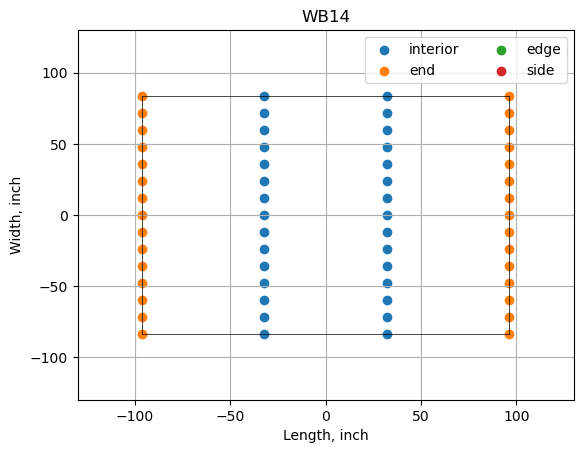

In [372]:
#_______________WB14__________________________________________________
interior_x, interior_y = support_group(2,15,12*5+4, 12) #purlin
end_x, end_y = support_group(2,15,12*16,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB14')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [378]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+4
lamda = 1/(1+(Ls/135)**2)
L = 16 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.719))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.524))

Iter   0 | F = 5.626103e-01 | IC = (-0.00, -81.33)
Iter  10 | F = 1.677587e-01 | IC = (-0.00, -50.36)
Iter  20 | F = 1.591917e-01 | IC = (-0.00, -49.95)
Iter  30 | F = 1.569179e-01 | IC = (-0.00, -49.84)
Iter  40 | F = 1.562963e-01 | IC = (-0.00, -49.81)
Iter  50 | F = 1.561252e-01 | IC = (-0.00, -49.80)
Iter  60 | F = 1.560780e-01 | IC = (-0.00, -49.80)
Iter  70 | F = 1.560650e-01 | IC = (-0.00, -49.80)
Iter  80 | F = 1.560614e-01 | IC = (-0.00, -49.80)
Iter  90 | F = 1.560604e-01 | IC = (-0.00, -49.80)
Iter 100 | F = 1.560601e-01 | IC = (-0.00, -49.80)
Iter 110 | F = 1.560601e-01 | IC = (-0.00, -49.80)
Iter 120 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 130 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 140 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 150 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 160 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 170 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 180 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 190 | F = 1.560600e-01 | I

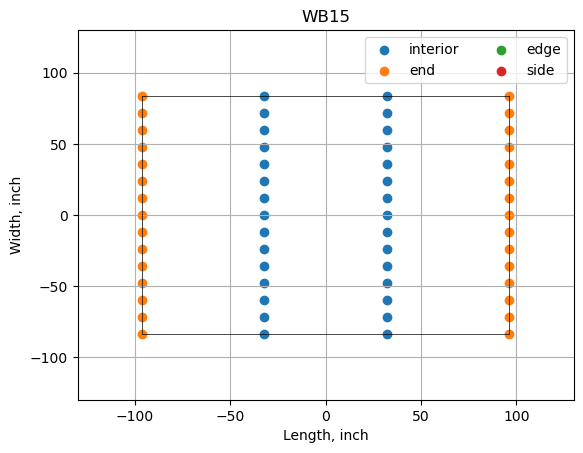

In [380]:
#_______________WB15__________________________________________________
interior_x, interior_y = support_group(2,15,12*5+4, 12) #purlin
end_x, end_y = support_group(2,15,12*16,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB15')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [386]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+4
lamda = 1/(1+(Ls/135)**2)
L = 16 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.694))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.524))

Iter   0 | F = 5.626103e-01 | IC = (-0.00, -81.33)
Iter  10 | F = 1.677587e-01 | IC = (-0.00, -50.36)
Iter  20 | F = 1.591917e-01 | IC = (-0.00, -49.95)
Iter  30 | F = 1.569179e-01 | IC = (-0.00, -49.84)
Iter  40 | F = 1.562963e-01 | IC = (-0.00, -49.81)
Iter  50 | F = 1.561252e-01 | IC = (-0.00, -49.80)
Iter  60 | F = 1.560780e-01 | IC = (-0.00, -49.80)
Iter  70 | F = 1.560650e-01 | IC = (-0.00, -49.80)
Iter  80 | F = 1.560614e-01 | IC = (-0.00, -49.80)
Iter  90 | F = 1.560604e-01 | IC = (-0.00, -49.80)
Iter 100 | F = 1.560601e-01 | IC = (-0.00, -49.80)
Iter 110 | F = 1.560601e-01 | IC = (-0.00, -49.80)
Iter 120 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 130 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 140 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 150 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 160 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 170 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 180 | F = 1.560600e-01 | IC = (-0.00, -49.80)
Iter 190 | F = 1.560600e-01 | I

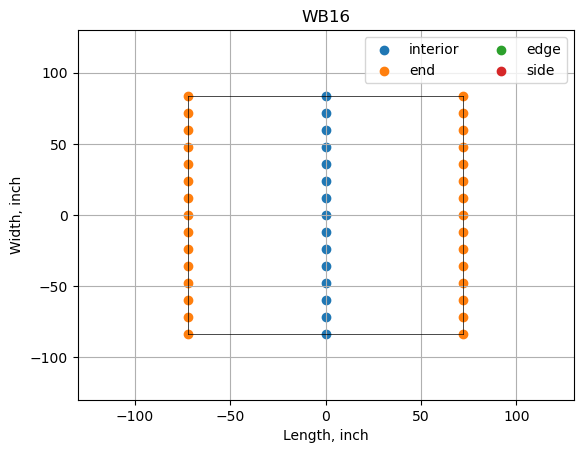

In [388]:
#_______________WB16__________________________________________________
interior_x, interior_y = support_group(1,15,12*6, 12) #purlin
end_x, end_y = support_group(2,15,12*12,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB16')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [394]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+0
lamda = 1/(1+(Ls/135)**2)
L = 12 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.498))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.491))

Iter   0 | F = 4.948587e-01 | IC = (-0.00, -64.00)
Iter  10 | F = 2.020013e-02 | IC = (-0.00, -42.04)
Converged at iteration 19, F = 7.8281e-04
Shear strength =  10.97 kips
Shear strength =   0.91 kips/ft
ICM/EXP = 1.84 
ICM/AISI = 1.86 


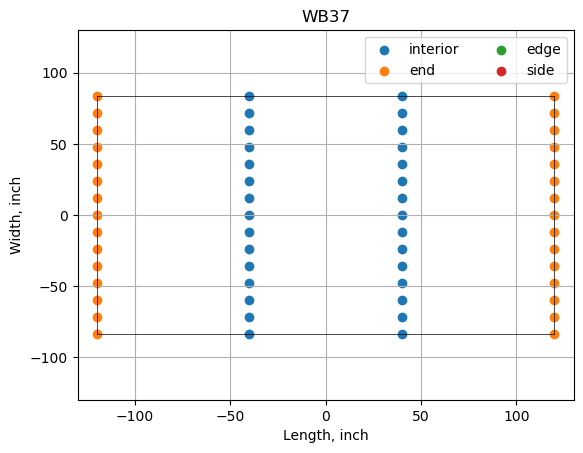

In [396]:
#_______________WB37__________________________________________________
interior_x, interior_y = support_group(2,15,12*6+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB37')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [402]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.409))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.401))

Iter   0 | F = 5.288325e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 3.830194e-01 | IC = (-0.00, -26.98)
Iter  20 | F = 3.867824e-01 | IC = (-0.00, -26.81)
Iter  30 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  40 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  50 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  60 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  70 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  80 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter  90 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 100 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 110 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 120 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 130 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 140 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 150 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 160 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 170 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 180 | F = 3.867849e-01 | IC = (-0.00, -26.81)
Iter 190 | F = 3.867849e-01 | 

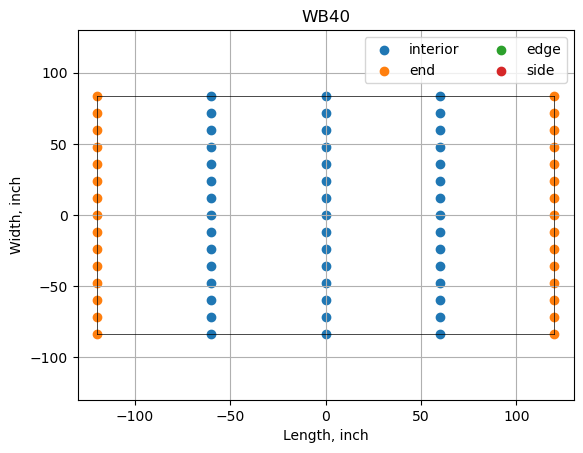

In [406]:
#_______________WB40__________________________________________________
interior_x, interior_y = support_group(3,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB40')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [412]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.696))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.541))

Iter   0 | F = 5.278854e-01 | IC = (-0.00, -103.00)
Iter  10 | F = 1.620684e-01 | IC = (-0.00, -36.79)
Iter  20 | F = 2.088805e-01 | IC = (-0.00, -35.10)
Iter  30 | F = 2.461991e-01 | IC = (-0.00, -33.36)
Iter  40 | F = 2.509673e-01 | IC = (-0.00, -33.14)
Iter  50 | F = 2.514955e-01 | IC = (-0.00, -33.12)
Iter  60 | F = 2.515530e-01 | IC = (-0.00, -33.11)
Iter  70 | F = 2.515593e-01 | IC = (-0.00, -33.11)
Iter  80 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter  90 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 100 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 110 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 120 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 130 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 140 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 150 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 160 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 170 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 180 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 190 | F = 2.515600e-01 | 

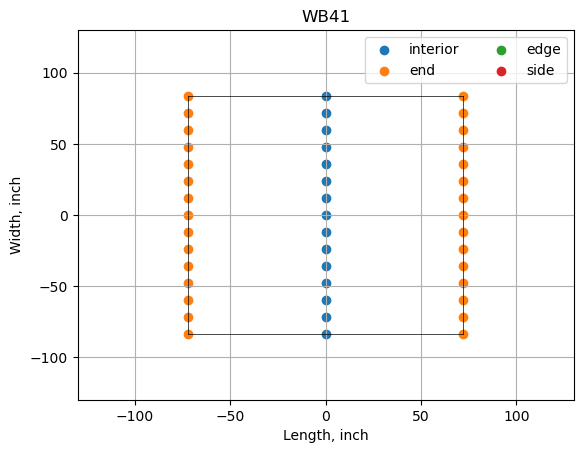

In [414]:
#WB 41
interior_x, interior_y = support_group(1,15,12*6, 12) #purlin
end_x, end_y = support_group(2,15,12*12,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB41')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [420]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 12 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.583))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.491))

Iter   0 | F = 5.011577e-01 | IC = (-0.00, -64.00)
Iter  10 | F = 2.180028e-02 | IC = (-0.00, -41.88)
Converged at iteration 19, F = 9.0395e-04
Shear strength =  10.65 kips
Shear strength =   0.89 kips/ft
ICM/EXP = 1.52 
ICM/AISI = 1.81 


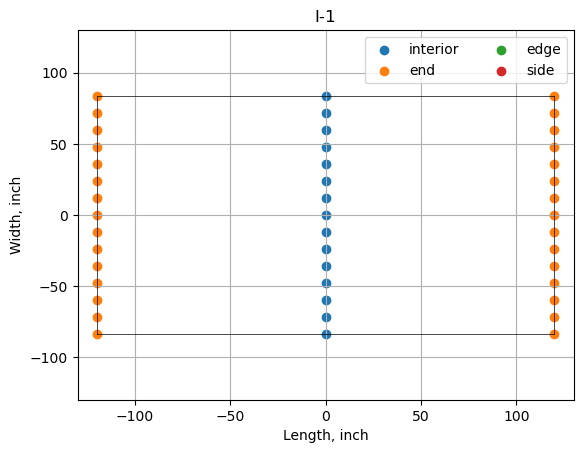

In [422]:
#I-1
interior_x, interior_y = support_group(1,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-1')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [428]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (10*12)+0
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.350))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.192))

Iter   0 | F = 5.334814e-01 | IC = (-0.00, -128.00)
Iter  10 | F = 5.360311e-01 | IC = (-0.00, -18.63)
Iter  20 | F = 5.110646e-01 | IC = (-0.00, -19.68)
Iter  30 | F = 5.382225e-01 | IC = (-0.00, -18.54)
Iter  40 | F = 4.875575e-01 | IC = (-0.00, -20.70)
Iter  50 | F = 5.629685e-01 | IC = (-0.00, -17.48)
Iter  60 | F = 5.494856e-01 | IC = (-0.00, -18.06)
Iter  70 | F = 5.705846e-01 | IC = (-0.00, -17.16)
Iter  80 | F = 4.960521e-01 | IC = (-0.00, -20.33)
Iter  90 | F = 4.981534e-01 | IC = (-0.00, -20.24)
Iter 100 | F = 5.655222e-01 | IC = (-0.00, -17.37)
Iter 110 | F = 5.313606e-01 | IC = (-0.00, -18.83)
Iter 120 | F = 4.396146e-01 | IC = (-0.00, -22.74)
Iter 130 | F = 5.403008e-01 | IC = (-0.00, -18.45)
Iter 140 | F = 4.663100e-01 | IC = (-0.00, -21.60)
Iter 150 | F = 5.692622e-01 | IC = (-0.00, -17.21)
Iter 160 | F = 5.046792e-01 | IC = (-0.00, -19.95)
Iter 170 | F = 5.256957e-01 | IC = (-0.00, -19.07)
Iter 180 | F = 5.476838e-01 | IC = (-0.00, -18.13)
Iter 190 | F = 5.140935e-01 | 

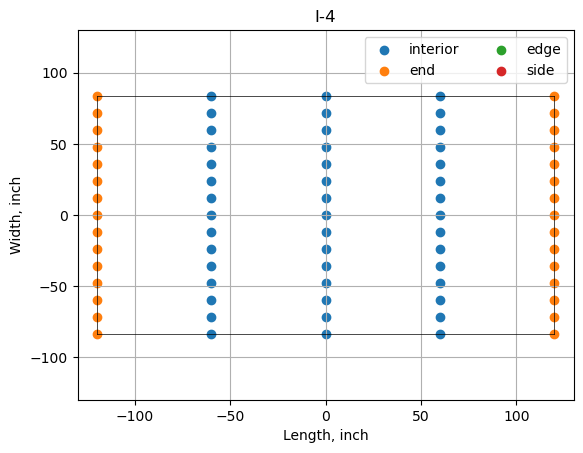

In [434]:
#I-4
interior_x, interior_y = support_group(3,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-4')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [446]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)

L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.535))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.423))

Iter   0 | F = 5.278854e-01 | IC = (-0.00, -103.00)
Iter  10 | F = 1.620684e-01 | IC = (-0.00, -36.79)
Iter  20 | F = 2.088805e-01 | IC = (-0.00, -35.10)
Iter  30 | F = 2.461991e-01 | IC = (-0.00, -33.36)
Iter  40 | F = 2.509673e-01 | IC = (-0.00, -33.14)
Iter  50 | F = 2.514955e-01 | IC = (-0.00, -33.12)
Iter  60 | F = 2.515530e-01 | IC = (-0.00, -33.11)
Iter  70 | F = 2.515593e-01 | IC = (-0.00, -33.11)
Iter  80 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter  90 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 100 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 110 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 120 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 130 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 140 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 150 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 160 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 170 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 180 | F = 2.515600e-01 | IC = (-0.00, -33.11)
Iter 190 | F = 2.515600e-01 | 

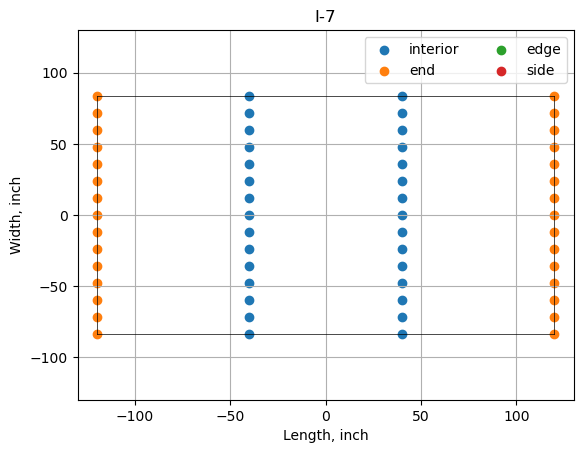

In [450]:
 #I-7
interior_x, interior_y = support_group(2,15,12*6+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-7')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [454]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.15 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.360))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.300))

Iter   0 | F = 4.110255e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 7.766477e-02 | IC = (-0.00, -41.20)
Iter  20 | F = 5.455630e-02 | IC = (-0.00, -42.40)
Iter  30 | F = 4.939603e-02 | IC = (-0.00, -42.68)
Iter  40 | F = 4.818445e-02 | IC = (-0.00, -42.74)
Iter  50 | F = 4.789611e-02 | IC = (-0.00, -42.76)
Iter  60 | F = 4.782727e-02 | IC = (-0.00, -42.76)
Iter  70 | F = 4.781082e-02 | IC = (-0.00, -42.76)
Iter  80 | F = 4.780689e-02 | IC = (-0.00, -42.76)
Iter  90 | F = 4.780596e-02 | IC = (-0.00, -42.76)
Iter 100 | F = 4.780573e-02 | IC = (-0.00, -42.76)
Iter 110 | F = 4.780568e-02 | IC = (-0.00, -42.76)
Iter 120 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 130 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 140 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 150 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 160 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 170 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 180 | F = 4.780566e-02 | IC = (-0.00, -42.76)
Iter 190 | F = 4.780566e-02 | 